# Lab 7.04 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests
import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation
from sklearn.linear_model import LinearRegression   # Linear regression model

# Time series analysis
from datetime import datetime
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose


### Exercise 4 - Airline ticket data

Consider the airline ticket data in the file airline ticket data.csv  

- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Create and train the model. Predict the values for the next 12 months.
- Create a plot with the airline ticket data and the predicted values for the next 12 months.

In [21]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])

data.index = pd.DatetimeIndex(data.index, freq='MS')

data.tail()

C:\Users\tijls\AppData\Local\Temp\ipykernel_50728\380957171.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])


,Tickets
Month,
2021-08-01,710
2021-09-01,673
2021-10-01,793
2021-11-01,852
2021-12-01,710


<Axes: xlabel='Month'>

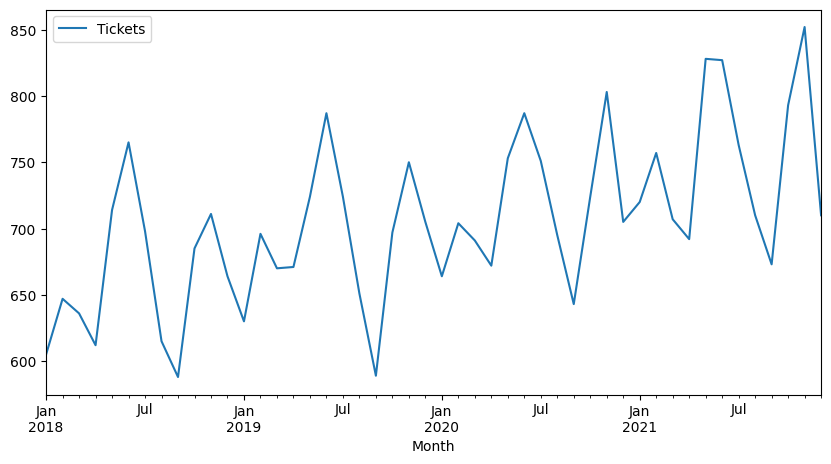

In [4]:
data.plot(y='Tickets', figsize=(10,5))

In [22]:
train = data[:'2021-11-01']

# data['SMA3'] = data['Tickets'].rolling(3).mean().shift(1)
data_tes = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()

<Axes: xlabel='Month'>

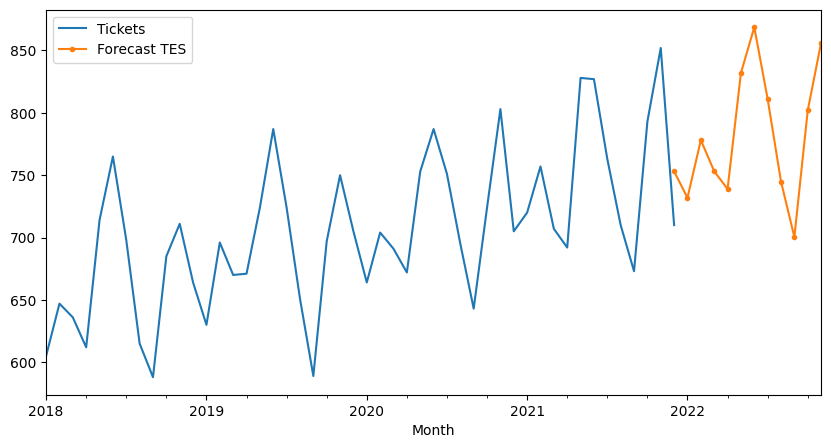

In [23]:
data_tes_forecast = data_tes.forecast(12)

data[['Tickets']].plot(legend=True, figsize=(10, 5))
data_tes_forecast.plot(marker='.', legend=True, label="Forecast TES")

## Source
Business Analytics Data Analysis & Decision Making 